# Node classification sweep performance - Region label prediction

Chen et al, 2022 data with region labels (white matter, Grey matter (Layer 1, 2, etc)..)

**Part 1: Robustness sweep**

Plots showing the performance for the region label classification.

- InterScale (GCN + Transformer)
- GCN
- PCATransformer



In [2]:
import os

# LRZ home
if os.path.exists("/dss/dsshome1/05/di93tig"):
    print('LRZ cluster')
    CLUSTER = 'LRZ'
    BASE_DIR_REPO = "/dss/dsshome1/05/di93tig/1_projects" 
    BASE_DIR_PROJECT = "/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale"
elif os.path.exists("/home/icb/francesca.drummer/"):
    print('HPC cluster')
    CLUSTER = 'HPC'
    BASE_DIR_REPO = "/home/icb/francesca.drummer/1-Projects/"
    BASE_DIR_PROJECT = ""
else:
    print('unkown')
    CLUSTER = 'unknown'
DATA = "chen22"

LRZ cluster


In [3]:
import sys
from pathlib import Path

# Add project root to path (go up 2 levels from notebook location)
project_root = Path(f'{BASE_DIR_REPO}/InterScale_reproducibility')
print(project_root)
sys.path.insert(0, str(project_root))

/dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility


In [4]:
import wandb
wandb.login()

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: francesca-drummer to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [5]:
import pandas as pd
# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
# InterScale imports
from InterScale.config import load_config_from_yaml, config_from_wandb_run

# utility function imports
from src.wandb import Wandb_evaluation, plot_f1_across_seeds, plot_class_f1_comparison, set_plot_configs
from src.plots import Plotting
from src.utils import set_full_reproducibility

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.10/dist-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /usr/local/lib/python3.10/dist-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSsb
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/usr/local/lib/python3.10/dist-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /usr/local/lib/python3.10/dist-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSsb
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
/usr/local/lib/python

In [42]:
import yaml
import matplotlib.pyplot as plt
import scanpy as sc

config_path = os.path.join(BASE_DIR_REPO, "InterScale_reproducibility/figures/config.yml")

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

PALETTE = config["palettes"]["continuous"]
CELL_TYPE_COLORS = config["palettes"][DATA]

from figures.scripts.plots import Plotting

plotting = Plotting(config_path)
plotting._setup_plotting_params()

## Hyperparameter sweep

Evaluation of node-classification (Cell type) hyperparameter sweep.

In [26]:
df = Dual_wandb.filter_runs(exclude_parameters = {"pct_mask_nodes":[0.0]})
df.head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,...,lr_warmup,batch_size,LC_num_layers,LC_hidden_dim,LC_dropout,GC_n_heads,GC_num_layers,GC_dim_feedforward,GC_hidden_dim,GC_dropout
0,sysappn2,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.50,110,None,205.602434,197842,0.151653,...,20,32,2,32,0.1,2,2,None,None,0.0
1,4um0v8yu,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.10,110,None,160.353546,464786,0.173032,...,30,32,2,64,0.1,4,2,None,None,0.3
2,g2mx3fkm,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.25,110,None,182.710215,105586,0.436869,...,10,16,1,32,0.3,4,1,None,None,0.0
3,w7knxdm4,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.25,110,None,149.468218,204050,0.086806,...,20,16,2,128,0.1,2,4,None,None,0.1
4,3gai2tif,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.10,110,None,193.831205,1682962,0.514339,...,10,32,2,512,0.3,2,4,None,None,0.3


In [ ]:
df

In [30]:
df[df['test_acc'] > 0.55]

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,...,lr_warmup,batch_size,LC_num_layers,LC_hidden_dim,LC_dropout,GC_n_heads,GC_num_layers,GC_dim_feedforward,GC_hidden_dim,GC_dropout
9,jaokfets,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.1,110,None,169.764292,519058,0.553819,...,40,32,1,512,0.1,2,4,None,None,0.0
43,7gfchrbo,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.1,110,None,181.978601,464786,0.571875,...,10,64,2,64,0.0,4,4,None,None,0.1
52,iigu25p9,dual_melton25_clas_node_44_GCN_self-attn-trans...,44,finished,0.5,110,None,169.006287,593426,0.577257,...,10,16,2,512,0.0,2,4,None,None,0.3


In [14]:
adata = sc.read_h5ad(os.path.join(BASE_DIR_PROJECT, "data/melton25.h5ad"))

In [13]:
Dual_wandb.export_config_to_yaml(best_run_id="jaokfets", save_path=f"{BASE_DIR_REPO}/InterScale_reproducibility/best_config.yaml")

Config saved to /dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility/best_config.yaml


'/dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility/best_config.yaml'

## 1. Robustness sweep

Run robustness sweep with config.yaml from best model. 

### Load WandB IDs

In [10]:
GNN_sweep = "8zpa634k"
DualInterScale_sweep = "mg6bc24j"
PCATrans_sweep = "0vn9y1n5"

## Graph Classification performance

In [11]:
SWEEP_GOAL = 'robustness'
CLASSES = ['Layer 1', 'Layer 2', 'Layer 3', 'Layer 4', 'Layer 5', 'Layer 6', 'White Matter']

Q: Why does PCATrans not have test_f1 scores?

In [13]:
GNN_wandb = Wandb_evaluation("GCN", GNN_sweep, True, False, SWEEP_GOAL, CLASSES)
PCATrans_wandb = Wandb_evaluation("PCATransformer", PCATrans_sweep, False, True, SWEEP_GOAL, CLASSES)
DualInterScale_wandb = Wandb_evaluation("DualInterScale", DualInterScale_sweep, True, True, SWEEP_GOAL, CLASSES)

In [14]:
GNN_wandb.get_dataframe().head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,test_f1_micro/avg,test_f1_class_Layer 1,test_f1_class_Layer 2,test_f1_class_Layer 3,test_f1_class_Layer 4,test_f1_class_Layer 5,test_f1_class_Layer 6,test_f1_class_White Matter
0,2mtwje30,Chen22_clas_node_40_GCN_,44,finished,0.5,None,None,159.807645,549047,0.619738,None,0.687118,0.675451,0.121156,0.099030,0.568004,0.433046,0.782207
1,s5gt15jr,Chen22_clas_node_40_GCN_,43,finished,0.5,None,None,164.889564,549047,0.607319,None,0.715771,0.707314,0.068077,0.094101,0.547716,0.382235,0.686150
2,oubw179s,Chen22_clas_node_40_GCN_,42,finished,0.5,None,None,164.711281,549047,0.549962,None,0.422906,0.584699,0.065264,0.014609,0.577447,0.451476,0.811674
3,blyote1k,Chen22_clas_node_40_GCN_,41,finished,0.5,None,None,159.685503,549047,0.622298,None,0.641940,0.576339,0.051768,0.153925,0.639128,0.548871,0.659346
4,26aptznw,Chen22_clas_node_40_GCN_,40,finished,0.5,None,None,178.213546,549047,0.581342,None,0.667275,0.696482,0.078345,0.189435,0.432874,0.495143,0.807097


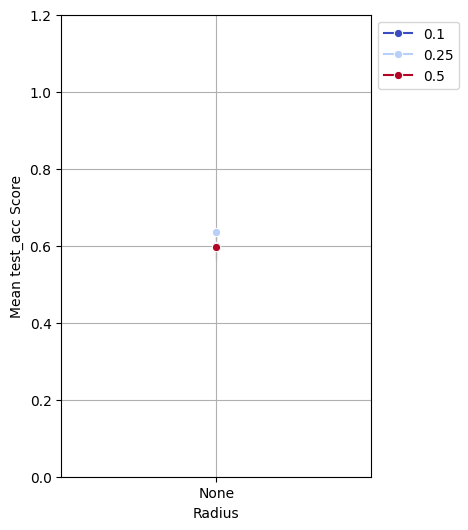

In [16]:
GNN_wandb.plot_robustness(metric="test_acc", save_path = f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class")

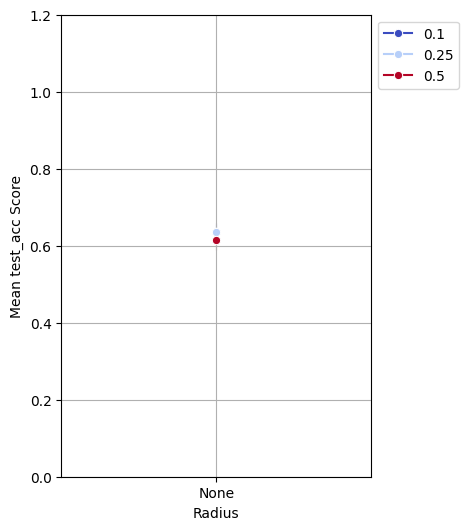

In [17]:
DualInterScale_wandb.plot_robustness(metric="test_acc", save_path =  f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class")

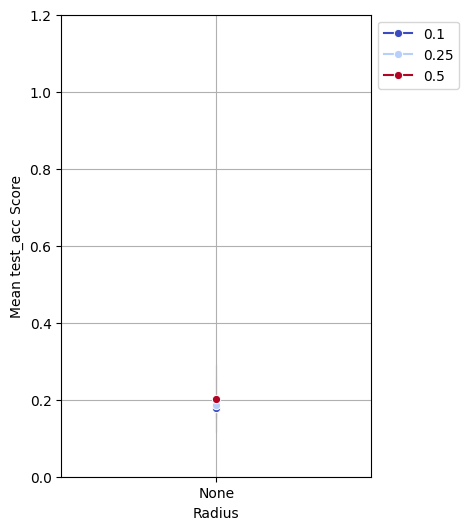

In [18]:
PCATrans_wandb.plot_robustness(metric="test_acc", save_path =  f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class")

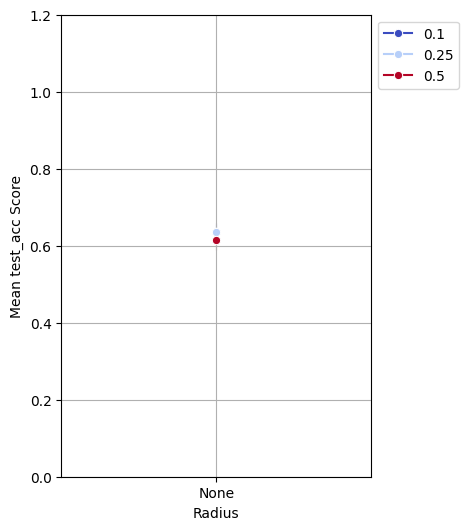

In [20]:
DualInterScale_wandb.plot_robustness(metric="test_acc", save_path =  f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class")

## F1 score performance

In [21]:
wandb_evals = [GNN_wandb, PCATrans_wandb, DualInterScale_wandb]  # Your list of dataframes, PCATrans_wandb, InterScale_wandb

## Class robustness

             model                       class      mean       std  n_seeds
0   DualInterScale       test_f1_class_Layer 1  0.726682  0.046401        5
1   DualInterScale       test_f1_class_Layer 2  0.679340  0.033556        5
2   DualInterScale       test_f1_class_Layer 3  0.088720  0.029408        5
3   DualInterScale       test_f1_class_Layer 4  0.089415  0.073114        5
4   DualInterScale       test_f1_class_Layer 5  0.525736  0.033094        5
5   DualInterScale       test_f1_class_Layer 6  0.432584  0.047913        5
6   DualInterScale  test_f1_class_White Matter  0.696008  0.049693        5
7              GCN       test_f1_class_Layer 1  0.627002  0.117254        5
8              GCN       test_f1_class_Layer 2  0.648057  0.062778        5
9              GCN       test_f1_class_Layer 3  0.076922  0.026484        5
10             GCN       test_f1_class_Layer 4  0.110220  0.066542        5
11             GCN       test_f1_class_Layer 5  0.553034  0.075331        5
12          

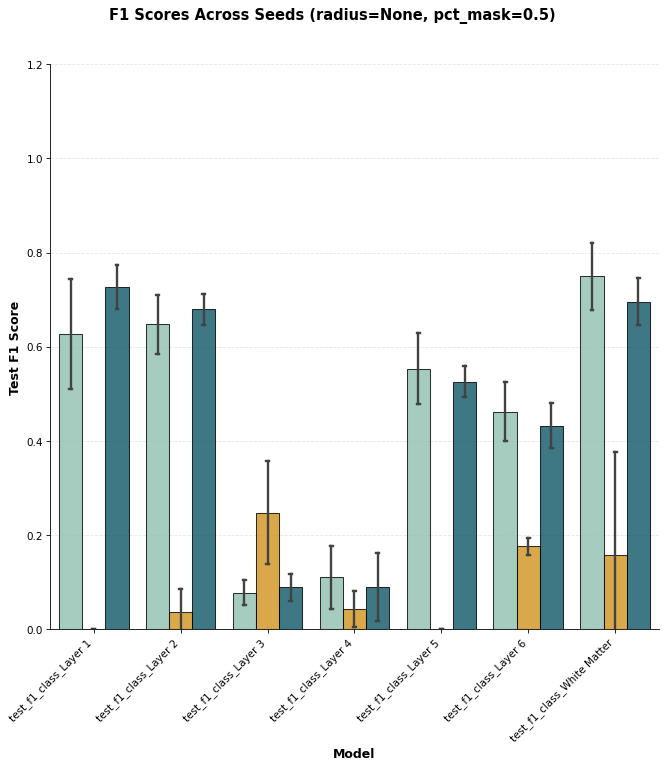

In [27]:
g, stats, plot_data = plot_f1_across_seeds(
    wandb_evaluations=wandb_evals,
    radius="None",
    pct_mask_nodes=0.5,
    BASE_DIR_REPO=BASE_DIR_REPO, 
    height=10,
    aspect=0.9,
    save_path=f'{DATA}/node_class/f1_comparison_models_radius'
)
plt.show()
#
# # Save with high DPI from config
# # g.savefig('f1_scores.png', bbox_inches='tight')
#
# # Print statistics:
# print(stats)

## Overall performance

How do the models perform overall? PLot Macro F1, Micro F1 & Accuracy.

In [81]:
def plot_overall_metric_comparison(wandb_evaluations, metric, radius=None, pct_mask_nodes=None, 
                                   BASE_DIR_REPO=None, save_path=None, figsize=(8, 5)):
    """
    Plot overall performance for a specific metric across models (aggregated across seeds).
    
    Parameters:
    -----------
    wandb_evaluations : list of Wandb_evaluation
    metric : str
        Column name of the metric to plot (e.g., 'test_f1_macro', 'test_accuracy', 'test_loss')
    radius, pct_mask_nodes : filter values (optional)
    BASE_DIR_REPO : str
    save_path : str, optional
    figsize : tuple
    
    Returns:
    --------
    fig, ax, stats_df
    """
    general_config, model_palette = set_plot_configs(BASE_DIR_REPO)
    
    all_data = []
    
    for wandb_eval in wandb_evaluations:
        df = wandb_eval.df.copy()
        model_name = wandb_eval.model
        
        if radius is not None:
            df = df[df['radius'] == radius]
        if pct_mask_nodes is not None:
            df = df[df['pct_mask_nodes'] == pct_mask_nodes]
        
        if df.empty:
            print(f"Warning: No data for {model_name} with specified filters")
            continue
        
        if metric not in df.columns:
            print(f"Warning: Metric '{metric}' not found for {model_name}")
            continue
        
        plot_df = df[['seed', metric]].copy() if 'seed' in df.columns else df[[metric]].copy()
        plot_df['model'] = model_name
        all_data.append(plot_df)
    
    if not all_data:
        raise ValueError("No valid data found for any model")
    
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Statistics
    stats_df = combined_df.groupby('model')[metric].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('n_seeds', 'count')
    ]).reset_index()
    print(stats_df)
    
    # Build palette
    palette = {m: model_palette[m] for m in combined_df['model'].unique() if m in model_palette}
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Replace the sns.barplot block with:
    models = stats_df['model'].tolist()
    means = stats_df['mean'].tolist()
    stds = stats_df['std'].tolist()
    colors = [palette.get(m, None) for m in models]
    
    x = np.arange(len(models))
    bar_width = 0.5
    ax.set_xlim(-0.4, len(models) - 0.4)
    
    ax.bar(x, means, yerr=stds, width=bar_width, color=colors,
           edgecolor='black', linewidth=1.0, alpha=0.8, capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    metric_label = metric.replace('_', ' ').replace('test ', '').title()
    ax.set_xlabel('Model', fontsize=general_config['legend_fontsize'], 
                  fontweight=general_config['legend_fontweight'])
    ax.set_ylabel(metric_label, fontsize=general_config['legend_fontsize'], 
                  fontweight=general_config['legend_fontweight'])
    ax.set_title(f'{metric_label} Across Seeds (radius={radius}, pct_mask={pct_mask_nodes})',
                 fontsize=general_config['title_fontsize'], 
                 fontweight=general_config['title_fontweight'])
    
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha('right')
    
    plt.tight_layout()
    
    if save_path is not None:
        plt.savefig(
            os.path.join(BASE_DIR_REPO, 'InterScale_reproducibility/figures/', f'{save_path}.jpg'),
            dpi=300, bbox_inches='tight'
        )
    
    plt.show()
    
    return fig, ax, stats_df

            model      mean       std  n_seeds
0  DualInterScale  0.634853  0.024430        5
1             GCN  0.598006  0.038667        5
2  PCATransformer  0.179582  0.027315        5


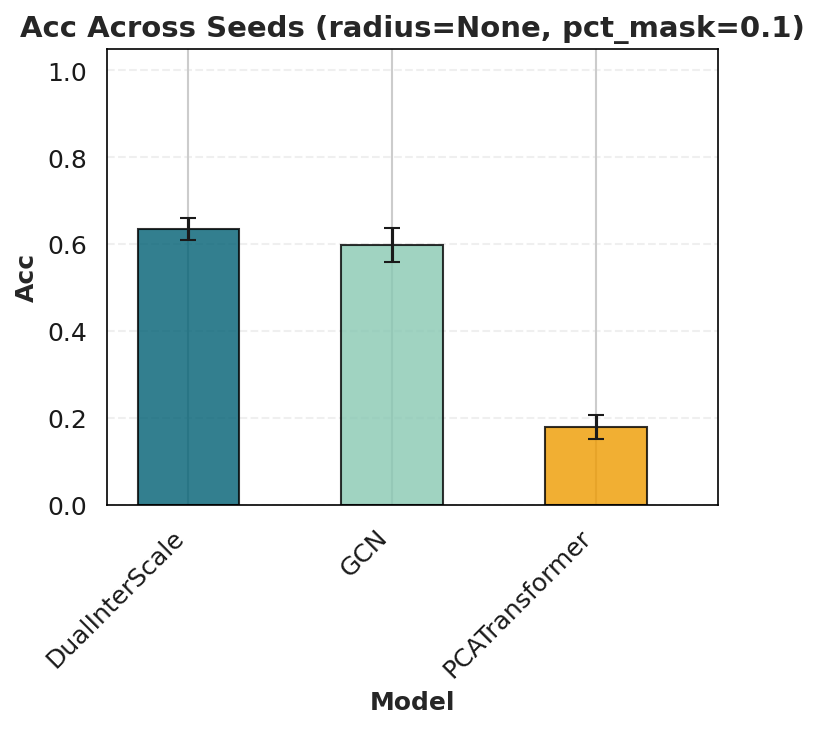

In [82]:
import numpy as np

fig, ax, stats = plot_overall_metric_comparison(
    wandb_evals,
    metric='test_acc',  # or 'test_accuracy', 'test_balanced_accuracy', etc.
    radius="None",
    pct_mask_nodes=0.1,
    BASE_DIR_REPO=BASE_DIR_REPO,
    save_path=f'{DATA}/overall_f1_macro_comparison',
    figsize=(5, 5)
)